In [40]:
import os
import re
import json
import math
import random
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, ViTImageProcessor, ViTModel, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


In [41]:
@dataclass
class Config:
    # Backbones
    vit_model_name: str = "google/vit-base-patch16-224"
    lm_model_name: str = "gpt2"
    tokenizer_name: str = "gpt2"

    # Dataset split names
    train_split: str = "train"
    val_split: str = "validation"

    # Sequence lengths
    max_total_len: int = 512
    max_gen_len: int = 128

    # Training
    batch_size: int = 4
    num_workers: int = 4
    num_epochs: int = 10
    lr: float = 1e-4
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    warmup_ratio: float = 0.06

    # GPT-2 hidden size is used automatically
    d_model: int = 768
    n_heads: int = 8
    num_layers: int = 6
    d_ff: int = 2048
    dropout: float = 0.1

    # Vision
    freeze_vit: bool = True

    # Faster experiment
    train_subset_size: int = 2000
    max_steps_per_epoch: Optional[int] = None

cfg = Config()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)

print("Using device:", DEVICE)
print(asdict(cfg))

Using device: cuda
{'vit_model_name': 'google/vit-base-patch16-224', 'lm_model_name': 'gpt2', 'tokenizer_name': 'gpt2', 'train_split': 'train', 'val_split': 'validation', 'max_total_len': 512, 'max_gen_len': 128, 'batch_size': 4, 'num_workers': 4, 'num_epochs': 10, 'lr': 0.0001, 'weight_decay': 0.0001, 'grad_clip': 1.0, 'warmup_ratio': 0.06, 'd_model': 768, 'n_heads': 8, 'num_layers': 6, 'd_ff': 2048, 'dropout': 0.1, 'freeze_vit': True, 'train_subset_size': 2000, 'max_steps_per_epoch': None}


In [42]:
class MiniVLM(nn.Module):
    """ViT image encoder + linear projector + pretrained GPT-2 decoder."""

    def __init__(
        self,
        lm_model_name: str,
        vit_model_name: str,
        pad_idx: int,
        freeze_vit: bool = True,
    ):
        super().__init__()

        self.vit = ViTModel.from_pretrained(vit_model_name)
        if freeze_vit:
            for p in self.vit.parameters():
                p.requires_grad = False

        self.lm = AutoModelForCausalLM.from_pretrained(lm_model_name)
        self.pad_idx = pad_idx
        self.hidden_size = self.lm.config.hidden_size

        vit_hidden_size = self.vit.config.hidden_size
        self.image_proj = nn.Linear(vit_hidden_size, self.hidden_size)

    def encode_image(self, pixel_values: torch.Tensor) -> torch.Tensor:
        vit_outputs = self.vit(pixel_values=pixel_values)
        image_feats = self.image_proj(vit_outputs.last_hidden_state)  # [B, N_img, H]
        return image_feats

    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None):
        image_feats = self.encode_image(pixel_values)  # [B, N_img, H]
        B, N_img, _ = image_feats.shape

        if attention_mask is None:
            attention_mask = (input_ids != self.pad_idx).long()

        text_embeds = self.lm.transformer.wte(input_ids)  # [B, T, H]
        inputs_embeds = torch.cat([image_feats, text_embeds], dim=1)  # [B, N_img+T, H]

        image_attention_mask = torch.ones(B, N_img, dtype=attention_mask.dtype, device=attention_mask.device)
        full_attention_mask = torch.cat([image_attention_mask, attention_mask], dim=1)

        outputs = self.lm.transformer(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attention_mask,
            use_cache=False,
            return_dict=True,
        )

        hidden_states = outputs.last_hidden_state[:, N_img:, :]  # keep text positions only
        lm_logits = self.lm.lm_head(hidden_states)

        return {
            "lm_logits": lm_logits,
            "image_feats": image_feats,
        }

In [43]:
# Initialize tokenizer and image processor
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)
processor = ViTImageProcessor.from_pretrained(cfg.vit_model_name)

# GPT-2 does not define a pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

PAD_IDX = tokenizer.pad_token_id
EOS_TOKEN = tokenizer.eos_token if tokenizer.eos_token is not None else ""

print("pad_token:", tokenizer.pad_token, PAD_IDX)
print("eos_token:", tokenizer.eos_token, tokenizer.eos_token_id)
print("vocab size:", len(tokenizer))

pad_token: <|endoftext|> 50256
eos_token: <|endoftext|> 50256
vocab size: 50257


In [44]:
# Build model, optimizer, and loss
model = MiniVLM(
    lm_model_name=cfg.lm_model_name,
    vit_model_name=cfg.vit_model_name,
    pad_idx=PAD_IDX,
    freeze_vit=cfg.freeze_vit,
).to(DEVICE)

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [45]:
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable parameters: 125,030,400


In [46]:
aokvqa_dataset = load_dataset("HuggingFaceM4/A-OKVQA", split="train", streaming=True)
# Collect samples
aokvqa_samples = []
for i, sample in enumerate(aokvqa_dataset):
    if i >= 2000:  # Use 2000 samples for training
        break
    aokvqa_samples.append(sample)

print(f"Loaded {len(aokvqa_samples)} A-OKVQA samples")

Loaded 2000 A-OKVQA samples


Sample keys: dict_keys(['image', 'question_id', 'question', 'choices', 'correct_choice_idx', 'direct_answers', 'difficult_direct_answer', 'rationales'])

Sample:
  Question: What is the man by the bags awaiting?
  Rationales: ['A train would not be on the street, he would not have luggage waiting for a delivery, and the skateboarder is there and not paying attention to him so a cab is the only possible answer.', 'He has bags as if he is going someone, and he is on a road waiting for vehicle that can only be moved on the road and is big enough to hold the bags.']...
  Choices: ['skateboarder', 'train', 'delivery', 'cab']
  Correct choice: 3


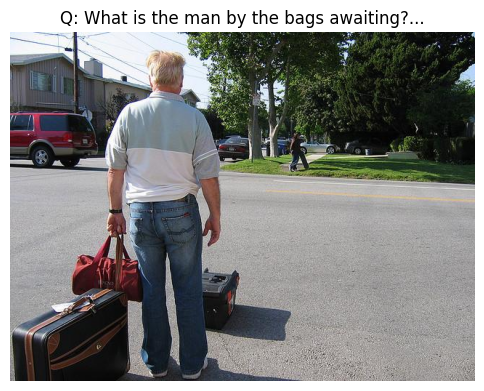

In [47]:
if aokvqa_samples:
    sample = aokvqa_samples[0]
    print("Sample keys:", sample.keys())
    print("\nSample:")

    if 'question' in sample:
        print(f"  Question: {sample['question']}")

    if 'rationales' in sample:
        print(f"  Rationales: {sample['rationales'][:2]}...")  # First 2

    if 'choices' in sample:
        print(f"  Choices: {sample['choices']}")

    if 'correct_choice_idx' in sample:
        print(f"  Correct choice: {sample['correct_choice_idx']}")

    # Display image
    if 'image' in sample:
        plt.figure(figsize=(6, 6))
        plt.imshow(sample['image'])
        plt.title(f"Q: {sample.get('question', 'N/A')[:50]}...")
        plt.axis('off')
        plt.show()

In [48]:
def format_cot_prompt(question, rationale, answer):
    """Format question, rationale, and answer as CoT prompt."""
    prompt = f"Question: {question}\nLet me think step by step:\n"
    response = f"{rationale}\nAnswer: {answer}"
    return prompt, response

class CoTReasoningDataset(Dataset):
    """Dataset for Chain-of-Thought visual reasoning."""

    def __init__(self, samples, image_processor, tokenizer, max_length=256):
        self.samples = samples
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Process image
        image = sample['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)

        # Extract question and answer
        question = sample.get('question', '')

        # Get answer
        if 'choices' in sample and 'correct_choice_idx' in sample:
            # A-OKVQA format
            answer = sample['choices'][sample['correct_choice_idx']]

        # Get rationale
        if 'rationales' in sample and sample['rationales']:
            # A-OKVQA has rationales
            rationale = random.choice(sample['rationales'])

        # Format as CoT
        prompt, response = format_cot_prompt(question, rationale, answer)
        full_text = f"{prompt}{response}{self.tokenizer.eos_token}"

        # Tokenize
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # Mask prompt (only train on reasoning + answer)
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)

        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'answer': answer,
        }

cot_dataset = CoTReasoningDataset(aokvqa_samples, processor, tokenizer)

cot_loader = DataLoader(
    cot_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)

print(f"CoT dataset: {len(cot_dataset)} samples")
print(f"Batches: {len(cot_loader)}")

CoT dataset: 2000 samples
Batches: 500


In [67]:
# Verify CoT format
sample_item = cot_dataset[0]
decoded = tokenizer.decode(sample_item['input_ids'], skip_special_tokens=True)
print("Sample CoT format:")
print(decoded[:300])

Sample CoT format:
Question: What is the man by the bags awaiting?
Let me think step by step:
A train would not be on the street, he would not have luggage waiting for a delivery, and the skateboarder is there and not paying attention to him so a cab is the only possible answer.
Answer: cab


In [50]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    total_valid_tokens = 0

    for step, batch in enumerate(dataloader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs["lm_logits"]

        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        valid_targets = (shift_labels != -100).sum().item()
        if valid_targets == 0:
            print(f"Step {step}: no valid targets, skipped.")
            continue

        B, Tm1, V = shift_logits.shape

        loss = loss_fn(
            shift_logits.view(B * Tm1, V),
            shift_labels.view(-1)
        )

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Step {step}: invalid loss, skipped.")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * valid_targets
        total_valid_tokens += valid_targets

        if step % 20 == 0:
            print(f"Step {step}/{len(dataloader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / max(total_valid_tokens, 1)
    return avg_loss

In [51]:
def train_model(model, train_loader, optimizer, loss_fn, device, num_epochs=3):
    history = []

    for epoch in range(num_epochs):
        print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")
        avg_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        history.append(avg_loss)
        print(f"Epoch {epoch+1} average loss: {avg_loss:.6f}")

    return history

In [52]:
history = train_model(
    model=model,
    train_loader=cot_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=DEVICE,
    num_epochs=10,
)


===== Epoch 1/10 =====
Step 0/500 | Loss: 7.1688
Step 20/500 | Loss: 3.2880
Step 40/500 | Loss: 4.1344
Step 60/500 | Loss: 2.8343
Step 80/500 | Loss: 3.0543
Step 100/500 | Loss: 3.3141
Step 120/500 | Loss: 2.9994
Step 140/500 | Loss: 2.3048
Step 160/500 | Loss: 3.0245
Step 180/500 | Loss: 2.9867
Step 200/500 | Loss: 2.6579
Step 220/500 | Loss: 2.5615
Step 240/500 | Loss: 3.1736
Step 260/500 | Loss: 2.5753
Step 280/500 | Loss: 2.6313
Step 300/500 | Loss: 2.2187
Step 320/500 | Loss: 3.0251
Step 340/500 | Loss: 2.1456
Step 360/500 | Loss: 3.4603
Step 380/500 | Loss: 2.4270
Step 400/500 | Loss: 2.4883
Step 420/500 | Loss: 2.6656
Step 440/500 | Loss: 2.8362
Step 460/500 | Loss: 3.0202
Step 480/500 | Loss: 2.4982
Epoch 1 average loss: 2.966403

===== Epoch 2/10 =====
Step 0/500 | Loss: 1.9178
Step 20/500 | Loss: 2.4420
Step 40/500 | Loss: 2.3705
Step 60/500 | Loss: 2.5595
Step 80/500 | Loss: 1.9111
Step 100/500 | Loss: 1.6223
Step 120/500 | Loss: 3.0238
Step 140/500 | Loss: 1.8830
Step 160/

In [53]:
@torch.no_grad()
def generate_vlm(
    model,
    pixel_values,
    prompt,
    tokenizer,
    device,
    max_new_tokens=100,
    temperature=0.7,
    do_sample=True,
):
    model.eval()

    pixel_values = pixel_values.to(device)

    prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    generated_ids = prompt_ids.clone()

    for _ in range(max_new_tokens):

        attention_mask = torch.ones_like(generated_ids, device=device)
        outputs = model(
            pixel_values=pixel_values,
            input_ids=generated_ids,
            attention_mask=attention_mask,
        )

        logits = outputs["lm_logits"]
        next_token_logits = logits[:, -1, :]

        if do_sample:
            probs = torch.softmax(next_token_logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        else:
            next_token = next_token_logits.argmax(dim=-1, keepdim=True)

        generated_ids = torch.cat([generated_ids, next_token], dim=1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [71]:
sample = cot_dataset[0]

pixel_values = sample["pixel_values"].unsqueeze(0)

question = cot_dataset.samples[0].get("question", "").strip()
prompt = f"Question: {question}\nLet me think step by step:\n"

generated_text = generate_vlm(
    model=model,
    pixel_values=pixel_values,
    prompt=prompt,
    tokenizer=tokenizer,
    device=DEVICE,
    max_new_tokens=80,
    temperature=0.8,
    do_sample=False,
)

print(generated_text)

Question: What is the man by the bags awaiting?
Let me think step by step:
He looks to be waiting for a paid ride to pick him up.
Answer: cab


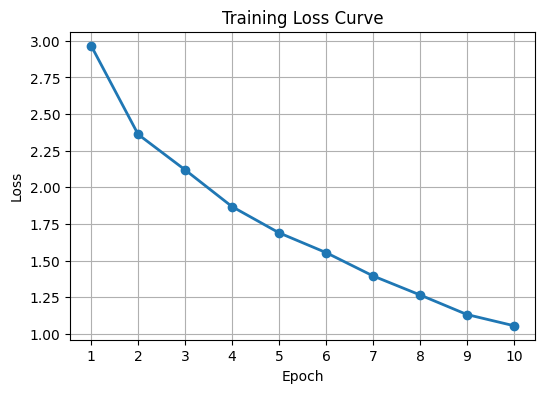

In [55]:
epochs = list(range(1, len(history) + 1))

plt.figure(figsize=(6,4))
plt.plot(epochs, history, marker='o', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.xticks(epochs)
plt.grid(True)

plt.show()

In [70]:
sample = cot_dataset[0]

pixel_values = sample["pixel_values"].unsqueeze(0)

question = cot_dataset.samples[0].get("question", "").strip()
prompt = f"Question: {question}"

generated_text = generate_vlm(
    model=model,
    pixel_values=pixel_values,
    prompt=prompt,
    tokenizer=tokenizer,
    device=DEVICE,
    max_new_tokens=80,
    temperature=0.8,
    do_sample=False,
)

print(generated_text)

Question: What is the man by the bags awaiting? a paid ride to pick him up.
Answer: cab


In [57]:
def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s)
    return s

def extract_answer(generated_text):
    text = generated_text.strip()

    if "Answer:" in text:
        ans = text.split("Answer:")[-1].strip().split("\n")[0].strip()
        return ans

    lines = [line.strip() for line in text.split("\n") if line.strip()]
    if len(lines) > 0:
        return lines[-1]

    return ""

In [58]:
num_samples = 100
correct_plain = 0
correct_cot = 0

results = []

model.eval()

for i in tqdm(range(num_samples)):
    sample = cot_dataset[i]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(DEVICE)

    raw_sample = cot_dataset.samples[i]
    question = raw_sample.get("question", "").strip()
    gold_answer = sample["answer"]

    prompt_plain = f"Question: {question}"
    prompt_cot = f"Question: {question}\nLet me think step by step:\n"

    pred_text_plain = generate_vlm(
        model=model,
        pixel_values=pixel_values,
        prompt=prompt_plain,
        tokenizer=tokenizer,
        device=DEVICE,
        max_new_tokens=80,
        temperature=0.8,
        do_sample=False,
    )

    pred_text_cot = generate_vlm(
        model=model,
        pixel_values=pixel_values,
        prompt=prompt_cot,
        tokenizer=tokenizer,
        device=DEVICE,
        max_new_tokens=80,
        temperature=0.8,
        do_sample=False,
    )

    pred_answer_plain = extract_answer(pred_text_plain)
    pred_answer_cot = extract_answer(pred_text_cot)

    gold_norm = normalize_text(gold_answer)
    plain_norm = normalize_text(pred_answer_plain)
    cot_norm = normalize_text(pred_answer_cot)

    plain_ok = int(plain_norm == gold_norm)
    cot_ok = int(cot_norm == gold_norm)

    correct_plain += plain_ok
    correct_cot += cot_ok

    results.append({
        "idx": i,
        "question": question,
        "gold_answer": gold_answer,
        "plain_pred": pred_answer_plain,
        "cot_pred": pred_answer_cot,
        "plain_correct": plain_ok,
        "cot_correct": cot_ok,
    })

plain_acc = correct_plain / num_samples
cot_acc = correct_cot / num_samples

print(f"Plain prompt accuracy: {plain_acc:.4f}")
print(f"CoT prompt accuracy:   {cot_acc:.4f}")
print(f"Difference (CoT - Plain): {cot_acc - plain_acc:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Plain prompt accuracy: 0.7100
CoT prompt accuracy:   0.8700
Difference (CoT - Plain): 0.1600


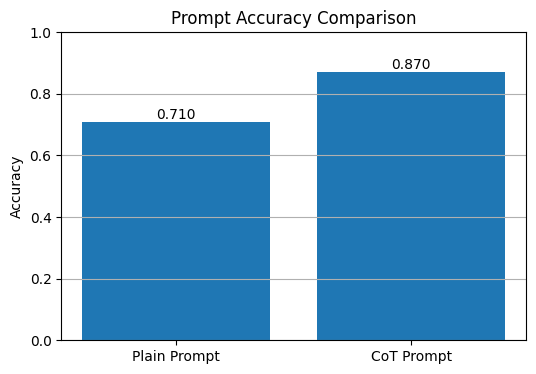

In [59]:
labels = ["Plain Prompt", "CoT Prompt"]
values = [plain_acc, cot_acc]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

plt.ylabel("Accuracy")
plt.title("Prompt Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(True, axis="y")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [68]:
for r in results[:10]:
    print("=" * 80)
    print("Q:", r["question"])
    print("Gold:", r["gold_answer"])
    print("Plain:", r["plain_pred"], "| correct =", r["plain_correct"])
    print("CoT  :", r["cot_pred"],   "| correct =", r["cot_correct"])

Q: What is the man by the bags awaiting?
Gold: cab
Plain: cab | correct = 1
CoT  : cab | correct = 1
Q: Where does this man eat pizza?
Gold: office
Plain: restaurant | correct = 0
CoT  : restaurant | correct = 0
Q: What is the occupation of the person driving?
Gold: farmer
Plain: farmer | correct = 1
CoT  : farmer | correct = 1
Q: How were the drivers of the cars able to park here?
Gold: airport workers
Plain: at work | correct = 0
CoT  : airport workers | correct = 1
Q: How many people can ride this motorcycle at a time?
Gold: two
Plain: two | correct = 1
CoT  : two | correct = 1
Q: Where would one most likely see the show advertised in the poster?
Gold: theater
Plain: theater | correct = 1
CoT  : theater | correct = 1
Q: What mood do the cows seem to be in?
Gold: happy
Plain: happy | correct = 1
CoT  : happy | correct = 1
Q: What type of rain is this called?
Gold: downpour
Plain: tropical | correct = 0
CoT  : downpour | correct = 1
Q: What is the man putting on the bus?
Gold: bow
Pla

# New Section